In [ ]:
# PhishTank EDA                                                                    
  Exploratory data analysis on the PhishTank verified phishing URL dataset.
  **Dataset:** `../data/raw/verified_online.csv`


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/verified_online.csv')
df['target'] = df['target'].str.replace('&amp;', '&', regex=False)
df.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:49+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:36+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:27:05+00:00,yes,2026-03-03T19:32:43+00:00,yes,Other
3,9358483,https://allegro.pl-oferta1081410.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:57+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro
4,9358482,http://allegrolokalnie.oferta362639327346393.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:42+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro


In [15]:
df.shape

(56045, 8)

In [3]:
df.dtypes

phish_id             int64
url                    str
phish_detail_url       str
submission_time        str
verified               str
verification_time      str
online                 str
target                 str
dtype: object

In [4]:
df['submission_time'] = pd.to_datetime(df['submission_time'])                    
df['verification_time'] = pd.to_datetime(df['verification_time'])
df.dtypes

phish_id                           int64
url                                  str
phish_detail_url                     str
submission_time      datetime64[us, UTC]
verified                             str
verification_time    datetime64[us, UTC]
online                               str
target                               str
dtype: object

In [ ]:
## Null / Missing Value Analysis

In [5]:
df.isnull().sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

In [6]:
(df == '').sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

In [ ]:
## Target Brand Distribution

In [7]:
target_counts = df['target'].value_counts().head(15)
print(target_counts)

target
Other                                  52773
Internal Revenue Service                 814
Allegro                                  654
Facebook                                 319
Microsoft                                185
Optus                                    147
DHL                                      102
AT&amp;T                                  77
Sumitomo Mitsui Banking Corporation       75
Amazon.com                                67
Bradesco                                  62
Netflix                                   61
PayPal                                    57
Adobe                                     47
eBay, Inc.                                41
Name: count, dtype: int64


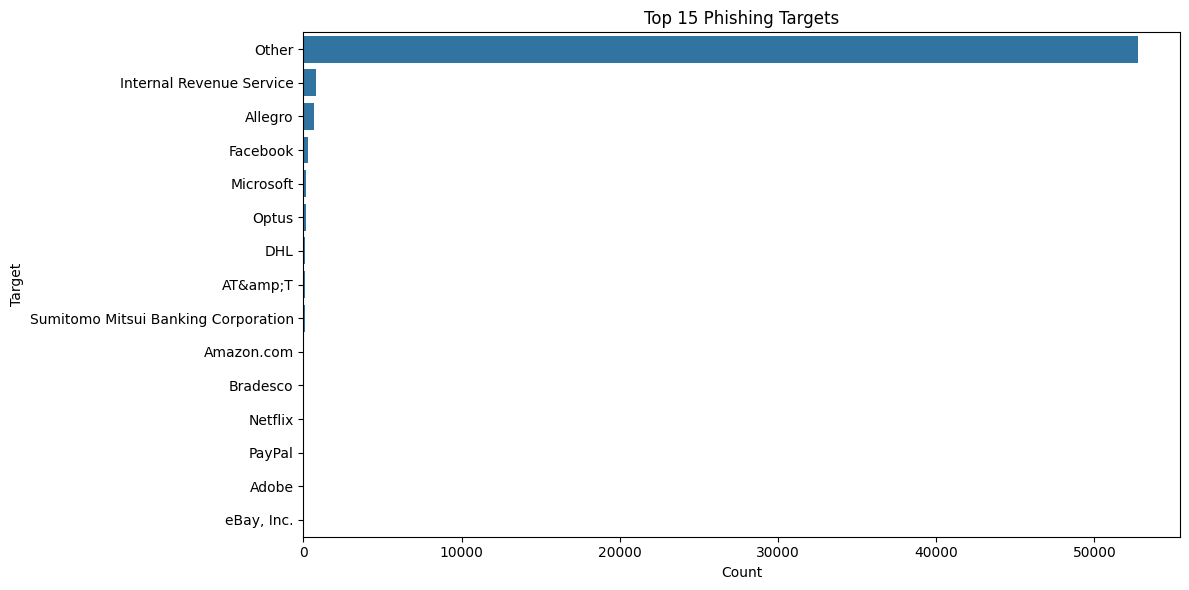

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts.values, y=target_counts.index)
plt.title('Top 15 Phishing Targets')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

In [ ]:
## "Other" accounts for the vast majority of targets. "Other" is excluded in the below chart but note this represents a small fraction of the full dataset 

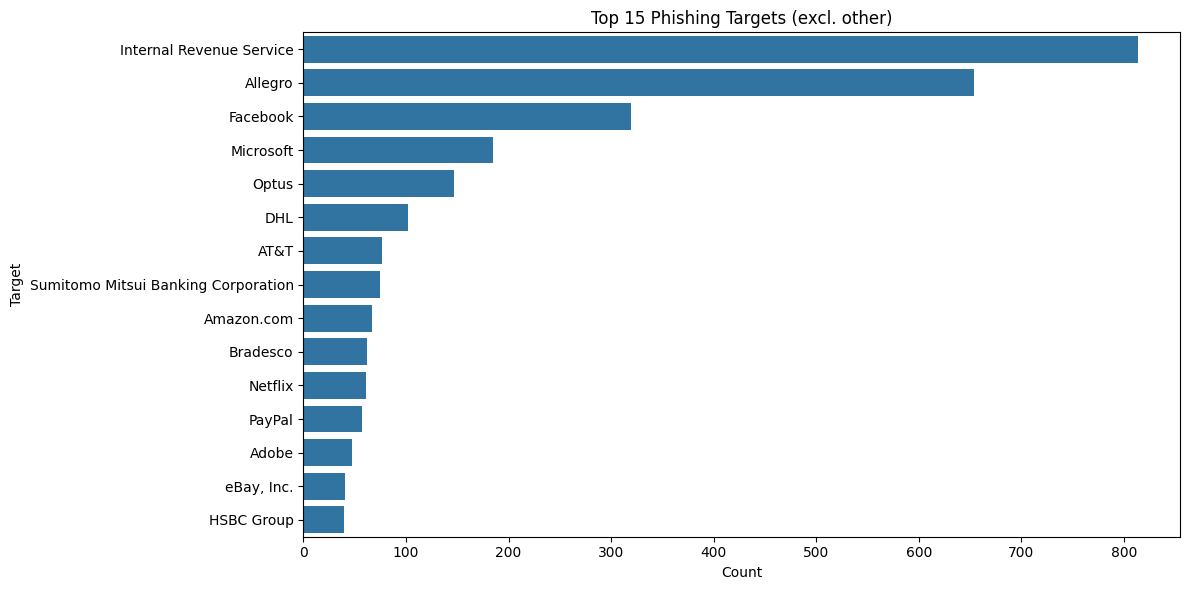

In [16]:
target_counts_filtered = df[df['target'] != 'Other']['target'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts_filtered.values, y=target_counts_filtered.index)
plt.title('Top 15 Phishing Targets (excl. other)')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

In [ ]:
## Online vs Offline Breakdown

online
yes    56045
Name: count, dtype: int64


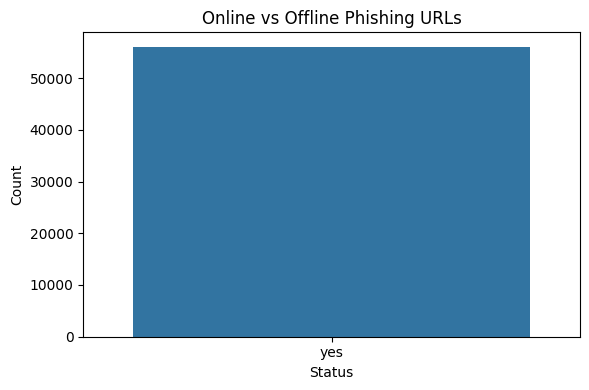

In [3]:
online_counts = df['online'].value_counts()
print(online_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=online_counts.index, y=online_counts.values)
plt.title('Online vs Offline Phishing URLs')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
## Dataset Limitations
# This dataset is only the verified online feed, meaning this dataset is a subset of the greater phishtank dataset. May want to redo and work with the full dataset. This dataset would be great for clustering/usupervised ML work: the dominance of 'Other' in the target category shows the opportunity to clean/mine this data for meaningful categorization.

In [ ]:
## Export Cleaned Dataset

In [4]:
df.to_csv('../data/processed/phishtank_cleaned.csv', index=False)
print("Success.")

Success.
